In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

In [4]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [5]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


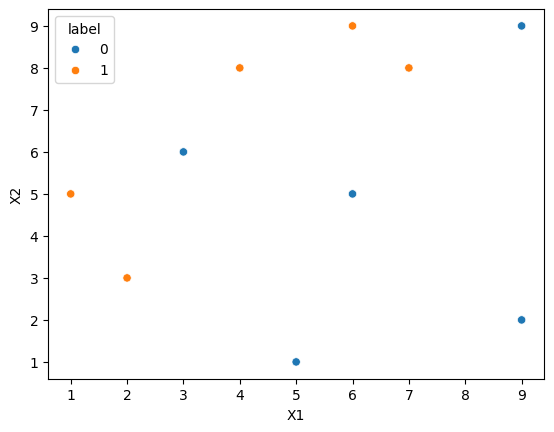

In [9]:
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])
plt.show()

In [10]:
df['weights'] = 1/df.shape[0]

In [11]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [14]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [15]:
dt1.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [16]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

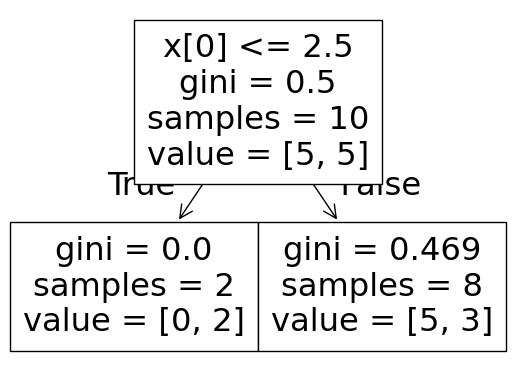

In [17]:
plot_tree(dt1)

<Axes: >

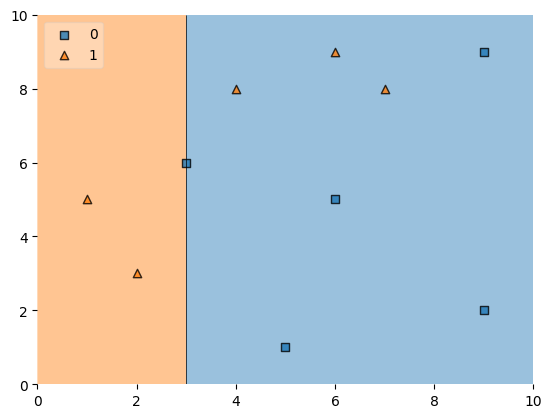

In [18]:
plot_decision_regions(X, y, dt1, legend=2)

In [19]:
df['y_pred'] = dt1.predict(X)

In [20]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [ ]:
#calculating the error for misclassified class
def error_calculate(df, y, pred, weight):
    return np.round(df[df['label'] != df['y_pred']]['weights'].sum(), 2)

In [38]:
error = error_calculate(df, 'lable', 'weights', 'y_pred')

In [39]:
#calculating the model's weight
def model_weight(error):
    return 0.5 * np.log((1-error)/error)

In [43]:
alplha1 = model_weight(error)
print(alplha1)

0.42364893019360184


In [45]:
#upsampling
#more weights for misclassified & less weight for correctly classified
def update_row_weights(row, alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [46]:
df['update_weights'] = df.apply(update_row_weights, axis=1)

In [47]:
df

,X1,X2,label,weights,y_pred,update_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [48]:
df['update_weights'].sum()

np.float64(0.9165153319682015)

In [49]:
df['normalized_weights'] = df['update_weights']/df['update_weights'].sum()

In [50]:
df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [51]:
df['normalized_weights'].sum()

np.float64(1.0)

In [ ]:
#upper range
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
#df['cumsum_upper'] = df['normalized_weights'].cumsum()

In [56]:
#lower range
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [58]:
df[['X1', 'X2', 'weights', 'y_pred', 'update_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,weights,y_pred,update_weights,cumsum_lower,cumsum_upper
0,1,5,0.1,1,0.065508,0.000000,0.071475
1,2,3,0.1,1,0.065508,0.071475,0.142950
2,3,6,0.1,0,0.065508,0.142950,0.214425
3,4,8,0.1,0,0.152653,0.214425,0.380983
4,5,1,0.1,0,0.065508,0.380983,0.452458
5,6,9,0.1,0,0.152653,0.452458,0.619017
6,6,5,0.1,0,0.065508,0.619017,0.690492
7,7,8,0.1,0,0.152653,0.690492,0.857050
8,9,9,0.1,0,0.065508,0.857050,0.928525
9,9,2,0.1,0,0.065508,0.928525,1.000000


In [78]:
#creating new dataset
def creating_new_data(df):
    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [79]:
index_value = creating_new_data(df)

In [80]:
index_value

[5, 8, 5, 0, 6, 7, 4, 7, 0, 9]

In [81]:
#creating second df
second_df = df.iloc[index_value, [0, 1, 2, 3]]

In [82]:
second_df

,X1,X2,label,weights
5,6,9,1,0.1
8,9,9,0,0.1
5,6,9,1,0.1
0,1,5,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
4,5,1,0,0.1
7,7,8,1,0.1
0,1,5,1,0.1
9,9,2,0,0.1


In [83]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [88]:
X = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [85]:
dt2.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[1] <= 3.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.625, 0.5, '  False')]

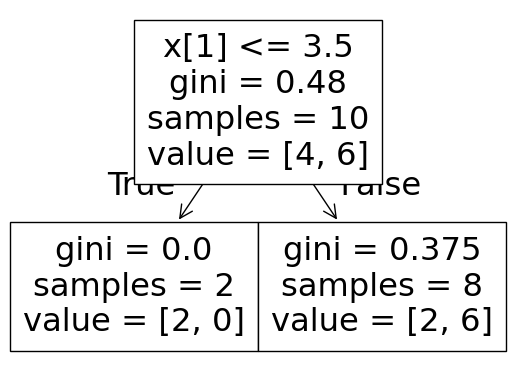

In [86]:
plot_tree(dt2)

<Axes: >

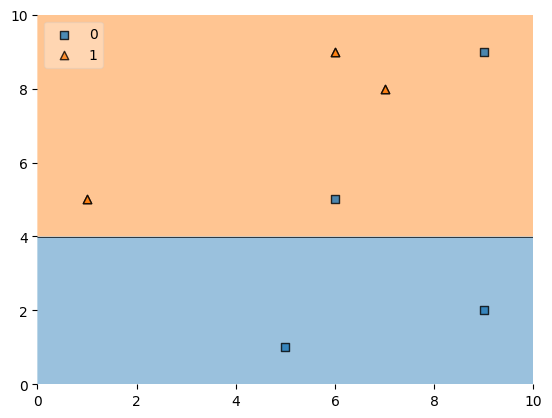

In [90]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [91]:
second_df['y_pred'] = dt2.predict(X)

In [92]:
second_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
8,9,9,0,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
4,5,1,0,0.1,0
7,7,8,1,0.1,1
0,1,5,1,0.1,1
9,9,2,0,0.1,0


In [93]:
error = error_calculate(second_df, 'label', 'y_pred', 'weights')

In [95]:
alpha2 = model_weight(error)

In [97]:
second_df['update_weights'] = second_df.apply(update_row_weights, axis=1)

In [98]:
second_df

,X1,X2,label,weights,y_pred,update_weights
5,6,9,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
5,6,9,1,0.1,1,0.065508
0,1,5,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
7,7,8,1,0.1,1,0.065508
0,1,5,1,0.1,1,0.065508
9,9,2,0,0.1,0,0.065508


In [99]:
second_df['normalized_weights'] = second_df['update_weights']/second_df['update_weights'].sum()

In [100]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [101]:
second_df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights,cumsum_upper,cumsum_lower
5,6,9,1,0.1,1,0.065508,0.078985,0.078985,0.000000
8,9,9,0,0.1,1,0.152653,0.184060,0.263045,0.078985
5,6,9,1,0.1,1,0.065508,0.078985,0.342030,0.263045
0,1,5,1,0.1,1,0.065508,0.078985,0.421015,0.342030
6,6,5,0,0.1,1,0.152653,0.184060,0.605074,0.421015
7,7,8,1,0.1,1,0.065508,0.078985,0.684060,0.605074
4,5,1,0,0.1,0,0.065508,0.078985,0.763045,0.684060
7,7,8,1,0.1,1,0.065508,0.078985,0.842030,0.763045
0,1,5,1,0.1,1,0.065508,0.078985,0.921015,0.842030
9,9,2,0,0.1,0,0.065508,0.078985,1.000000,0.921015


In [102]:
second_df[['X1', 'X2', 'label', 'y_pred', 'update_weights', 'cumsum_lower', 'cumsum_upper']]

,X1,X2,label,y_pred,update_weights,cumsum_lower,cumsum_upper
5,6,9,1,1,0.065508,0.000000,0.078985
8,9,9,0,1,0.152653,0.078985,0.263045
5,6,9,1,1,0.065508,0.263045,0.342030
0,1,5,1,1,0.065508,0.342030,0.421015
6,6,5,0,1,0.152653,0.421015,0.605074
7,7,8,1,1,0.065508,0.605074,0.684060
4,5,1,0,0,0.065508,0.684060,0.763045
7,7,8,1,1,0.065508,0.763045,0.842030
0,1,5,1,1,0.065508,0.842030,0.921015
9,9,2,0,0,0.065508,0.921015,1.000000


In [103]:
index_value = creating_new_data(second_df)

In [104]:
third_df = second_df.iloc[index_value, [0, 1, 2, 3]]

In [106]:
third_df

,X1,X2,label,weights
4,5,1,0,0.1
7,7,8,1,0.1
4,5,1,0,0.1
4,5,1,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
9,9,2,0,0.1
4,5,1,0,0.1


In [107]:
dt3 = DecisionTreeClassifier(max_depth=1)

In [108]:
X = third_df.iloc[:, 0:2].values
y = third_df.iloc[:, 2].values

In [109]:
dt3.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[1] <= 5.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

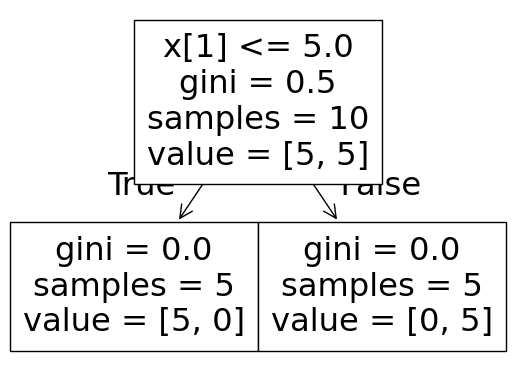

In [110]:
plot_tree(dt3)

<Axes: >

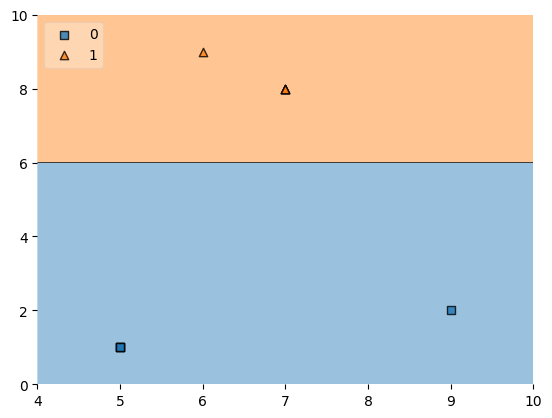

In [112]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [113]:
third_df['y_pred'] = dt3.predict(X)

In [114]:
third_df

,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
7,7,8,1,0.1,1
4,5,1,0,0.1,0
4,5,1,0,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
9,9,2,0,0.1,0
4,5,1,0,0.1,0


In [117]:
error = error_calculate(third_df, 'label', 'weights', 'y_pred')

In [120]:
print(error)

0.0


**prediction**

In [123]:
query = np.array([2, 3]).reshape(1, 2)

In [124]:
#first model
dt1.predict(query)

array([1])

In [125]:
dt2.predict(query)

array([0])

In [126]:
dt3.predict(query)

array([0])

In [128]:
np.sign(alplha1*1+alpha2*(-1))

np.float64(-1.0)

In [129]:
query = np.array([9, 9]).reshape(1, 2)

In [130]:
dt1.predict(query)

array([0])

In [131]:
dt2.predict(query)

array([1])

In [132]:
np.sign(alplha1*(-1) + alpha2*1)

np.float64(1.0)